In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv('../Data/clean_data/master_player_season.csv')
df_valid = df[df['low_sample'] == False].copy()

seasons_all = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
df_valid = df_valid[df_valid['season_name'].isin(seasons_all)]


/var/folders/hh/y__nk_xn2r5bz4qkvhyp3qpw0000gn/T/ipykernel_16741/703861256.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(50, 'vorp'))


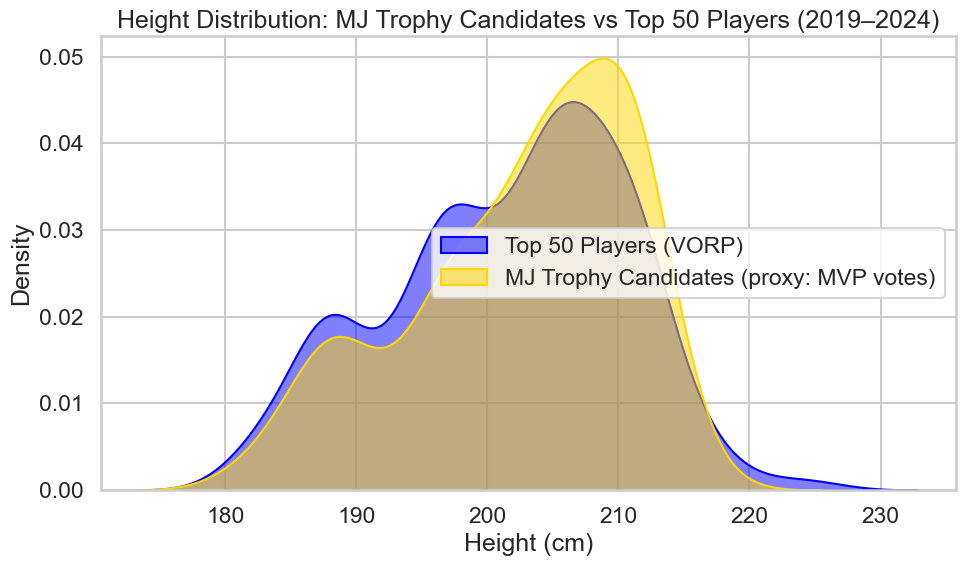

In [44]:
# Q1
top_50 = (
    df_valid.groupby('season_name', group_keys=False)
    .apply(lambda x: x.nlargest(50, 'vorp'))
    .reset_index(drop=True)
)
mj_trophy = df_valid[df_valid['is_mvp_candidate'] == True]

plt.figure(figsize=(10, 6))
sns.kdeplot(top_50['height_cm'].dropna(), label='Top 50 Players (VORP)', fill=True, alpha=0.5, color='blue')
sns.kdeplot(mj_trophy['height_cm'].dropna(), label='MJ Trophy Candidates (proxy: MVP votes)', fill=True, alpha=0.5, color='gold')
plt.title('Height Distribution: MJ Trophy Candidates vs Top 50 Players (2019–2024)')
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/hh/y__nk_xn2r5bz4qkvhyp3qpw0000gn/T/ipykernel_16741/571175925.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(15, 'vorp'))


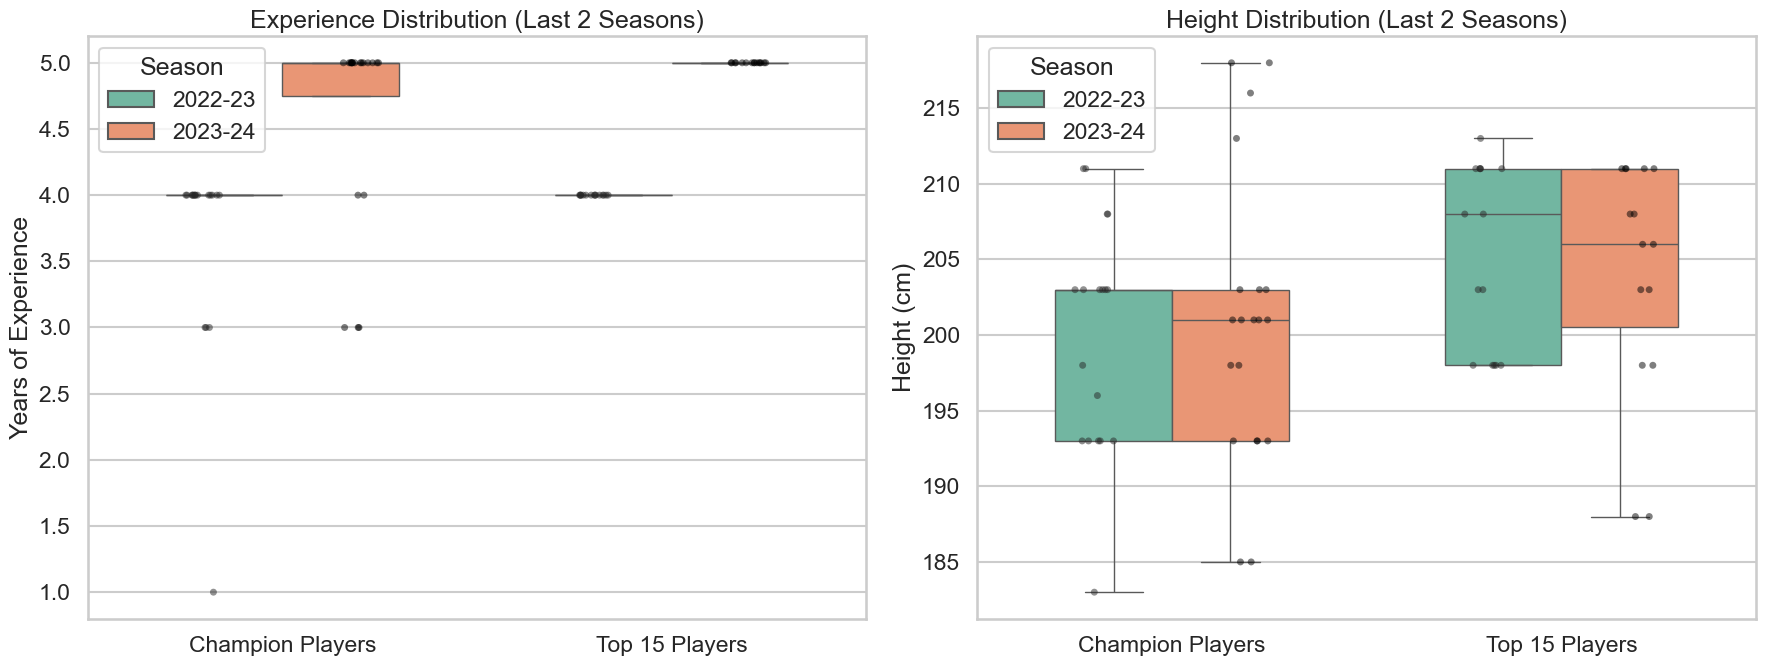

In [45]:
# Q2
 
recent_seasons = ['2022-23', '2023-24']
df_recent = df_valid[df_valid['season_name'].isin(recent_seasons)].copy()

df_recent['experience'] = df_recent['experience'].replace({'R': 0, 'None': 0})
df_recent['experience'] = pd.to_numeric(df_recent['experience'], errors='coerce')

champions = df_recent[df_recent['is_champion'] == True].copy()
champions['group'] = 'Champion Players'

top_15 = (
    df_recent.groupby('season_name', group_keys=False)
    .apply(lambda x: x.nlargest(15, 'vorp'))
    .reset_index(drop=True)
)
top_15['group'] = 'Top 15 Players'

combined = pd.concat([champions, top_15], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, col, ylabel, title in [
    (axes[0], 'experience', 'Years of Experience', 'Experience Distribution (Last 2 Seasons)'),
    (axes[1], 'height_cm', 'Height (cm)', 'Height Distribution (Last 2 Seasons)'),
]:
    sns.boxplot(
        ax=ax, data=combined, x='group', y=col,
        hue='season_name', palette='Set2', width=0.6, fliersize=0
    )
    sns.stripplot(
        ax=ax, data=combined, x='group', y=col,
        hue='season_name', palette='dark:black', dodge=True,
        alpha=0.5, size=5, jitter=True, legend=False
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Season', loc='upper left')

plt.tight_layout()
plt.show()





In [46]:
# Q3

true_pg_2024 = df_valid[
    (df_valid['season_name'] == '2023-24') & 
    (df_valid['position_code'] == 'PG')
]['player_id'].unique()

pg_mvp = df_valid[
    (df_valid['is_mvp_candidate'] == True) & 
    (df_valid['player_id'].isin(true_pg_2024))
]

pg_recommendations = (
    pg_mvp.groupby(['player_id', 'full_name'])
    .agg(
        mj_trophy_appearances=('season_id', 'nunique'),   
        avg_mvp_share=('mvp_share', 'mean'),
        avg_vorp=('vorp', 'mean')
    )
    .reset_index()
    .sort_values(['mj_trophy_appearances', 'avg_mvp_share'], ascending=[False, False])
)

print("Top 3 recommendations for the Point Guard position (active players):")
print(pg_recommendations.head(3).to_string(index=False))



Top 3 recommendations for the Point Guard position (active players):
player_id             full_name  mj_trophy_appearances  avg_mvp_share  avg_vorp
antetgi01 Giannis Antetokounmpo                      5       0.538400      6.44
doncilu01           Luka Dončić                      5       0.193600      6.20
jamesle01          LeBron James                      3       0.249333      5.00


In [47]:
# فرضیه اول 

df_unique = df_valid.drop_duplicates(subset=['player_id', 'season_id'])

past_seasons = ['2020-21', '2021-22']
new_seasons  = ['2022-23', '2023-24']

def get_top20_agility(seasons):
    return (
        df_unique[df_unique['season_name'].isin(seasons)]
        .groupby('season_name', group_keys=False)
        .apply(lambda x: x.nlargest(20, 'vorp'))
        ['agility'].dropna()
    )

agility_past = get_top20_agility(past_seasons)
agility_new  = get_top20_agility(new_seasons)

_, p_norm_past = stats.shapiro(agility_past)
_, p_norm_new  = stats.shapiro(agility_new)
print(f"Shapiro-Wilk — past: p={p_norm_past:.4f} | new: p={p_norm_new:.4f}")

alpha = 0.05
if (p_norm_past > alpha) and (p_norm_new > alpha):
    print("Both groups normal -> Welch's t-test")
    stat, p_value = stats.ttest_ind(agility_new, agility_past, equal_var=False, alternative='greater')
    test_name = "Welch's t-test"
else:
    print("Non-normal -> Mann-Whitney U test")
    stat, p_value = stats.mannwhitneyu(agility_new, agility_past, alternative='greater')
    test_name = "Mann-Whitney U"

print(f"\n[{test_name}] mean_past={agility_past.mean():.4f} | mean_new={agility_new.mean():.4f}")
print(f"Statistic={stat:.4f} | P-value={p_value:.4f}")
print("Reject H0: agility increased." if p_value < alpha else "Fail to reject H0: no significant increase.")



Shapiro-Wilk — past: p=0.2791 | new: p=0.1785
Both groups normal -> Welch's t-test

[Welch's t-test] mean_past=1.9803 | mean_new=2.0045
Statistic=0.5072 | P-value=0.3067
Fail to reject H0: no significant increase.


/var/folders/hh/y__nk_xn2r5bz4qkvhyp3qpw0000gn/T/ipykernel_16741/752212642.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(20, 'vorp'))
/var/folders/hh/y__nk_xn2r5bz4qkvhyp3qpw0000gn/T/ipykernel_16741/752212642.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(20, 'vorp'))


In [48]:
# فرضیه دوم

past_seasons = ['2020-21', '2021-22']
new_seasons  = ['2022-23', '2023-24']

df_unique = df_valid.drop_duplicates(subset=['player_id', 'season_id'])

champ_past = df_unique[
    (df_unique['season_name'].isin(past_seasons)) &
    (df_unique['is_champion'] == True)
]
champ_new = df_unique[
    (df_unique['season_name'].isin(new_seasons)) &
    (df_unique['is_champion'] == True)
]

innate_past = champ_past['innate_ability'].dropna()
innate_new  = champ_new['innate_ability'].dropna()

_, p_norm_ip = stats.shapiro(innate_past)
_, p_norm_in = stats.shapiro(innate_new)
print(f"Shapiro-Wilk innate_ability — past: p={p_norm_ip:.4f} | new: p={p_norm_in:.4f}")

both_normal_i = (p_norm_ip > alpha) and (p_norm_in > alpha)

if both_normal_i:
    print("Both groups normal -> Welch's t-test")
    t_stat_i, p_val_i = stats.ttest_ind(innate_new, innate_past, equal_var=False, alternative='greater')
    test_name_i = "Welch's t-test"
else:
    print("At least one group non-normal -> Mann-Whitney U test")
    t_stat_i, p_val_i = stats.mannwhitneyu(innate_new, innate_past, alternative='greater')
    test_name_i = "Mann-Whitney U"

print(f"\n[{test_name_i}] Mean past: {innate_past.mean():.4f} | Mean new: {innate_new.mean():.4f}")
print(f"Statistic: {t_stat_i:.4f} | P-value: {p_val_i:.4f}")

if p_val_i < alpha:
    print("Result: H0 rejected. Expert claim is statistically supported.")
else:
    print("Result: H0 not rejected.")

print(f"\nMean age (past champions): {champ_past['age'].mean():.2f}")
print(f"Mean age (new champions):  {champ_new['age'].mean():.2f}")



Shapiro-Wilk innate_ability — past: p=0.9836 | new: p=0.1720
Both groups normal -> Welch's t-test

[Welch's t-test] Mean past: 0.0842 | Mean new: 0.1480
Statistic: 7.2960 | P-value: 0.0000
Result: H0 rejected. Expert claim is statistically supported.

Mean age (past champions): 27.52
Mean age (new champions):  27.67
